In [147]:
import datetime
import os
from glob import glob

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from matplotlib.ticker import MultipleLocator

### Load data

In [2]:
data_path = 'ME4OH_EN411_OFAM3/data/en4.1.1/1993-2014/'
files = [f for f in glob(os.path.join(data_path, "*.nc"))]

In [3]:
file2read = nc.Dataset(files[0],'r')
print(file2read.variables.keys())

dict_keys(['en4_lat', 'en4_lon', 'en4_ymd', 'en4_ydec', 'en4_maxdepth', 'en4_wmo_inst_type', 'en4_project_name', 'en4_platform_number', 'en4_instrument_type', 'en4_inst_reference', 'en4_data_centre', 'ts_lat', 'ts_lon', 'ts_z', 'ts_dz', 'ts_bound', 'eta_t', 'sst', 'dohc', 'adohc', 'dohc_mask_by_en4_maxdepth', 'temp', 'salt'])


In [4]:
def load_and_filter_ohc(filepath):
    """Load data file, extract variables, filter for layer 1 OHC"""
    file_data = nc.Dataset(filepath,'r')

    # Extract variables
    lat = file_data["ts_lat"][:].data  # Latitude
    long = file_data["ts_lon"][:].data  # Longitude
    time = file_data["en4_ymd"][:].data  # Year , month , day
    mask = file_data["dohc_mask_by_en4_maxdepth"][:].data # Valid profile mask
    dohc1 = file_data["dohc"][:, 0].data  # Layer 1 OHC anomaly target (NOTE: index 0 in python, index 1 in R)
    ssh = file_data["eta_t"][:].data  # Sea surface height
    wmo_inst_type = file_data["en4_wmo_inst_type"][:].data
    proj_name = file_data["en4_project_name"][:].data
    plat_num = file_data["en4_platform_number"][:].data

    # Filter to valid OHC
    # Only valid Layer-1 profiles included according to mask and remove NaNs
    idx = [i for i in range(len(mask)) if mask[i, 0] == 1]
    filtered_dohc1 = np.array([dohc1[i] for i in idx])
    filtered_lat = np.array([lat[i] for i in idx])
    filtered_long = np.array([long[i] for i in idx])
    filtered_date = np.array([datetime.date(int(time[i, 0]), int(time[i, 1]), int(time[i, 2])) for i in idx])
    filtered_ssh = np.array([ssh[i] for i in idx])
    filtered_wmo = np.array([''.join(list(map(lambda x: x.decode('utf-8'), wmo_inst_type[i]))).strip() for i in idx])
    filtered_proj_name = np.array([''.join(list(map(lambda x: x.decode('utf-8'), proj_name[i]))).strip() for i in idx])
    filtered_plat_num = np.array([''.join(list(map(lambda x: x.decode('utf-8'), plat_num[i]))).strip() for i in idx])

    # Make df
    ohc_df = pd.DataFrame({
        "Date": filtered_date,
        "Latitude": filtered_lat,
        "Longitude": filtered_long,
        "OHC": filtered_dohc1,
        "SSH": filtered_ssh,
        "WMO Instrument Type": filtered_wmo,
        "Project name": filtered_proj_name,
        "Platform number": filtered_plat_num
    })
    ohc_df = ohc_df.dropna()
    
    return ohc_df
    

In [5]:
# Temporarily filter to only 10 files
# files = files[0:10]

In [6]:
# Read all files
ohc_df = load_and_filter_ohc(files[0])
for path in files[1:]:
    file_df = load_and_filter_ohc(path)
    ohc_df = pd.concat([ohc_df, file_df])

ohc_df

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number
0,1993-09-12,-65.050003,236.649994,0.343876,-1.691031,831,GTSPPPF 00,0219
1,1993-09-10,-64.050003,221.550003,0.344592,-1.746879,831,GTSPPPF 00,0218
2,1993-09-15,-63.549999,244.350006,0.345307,-1.345561,831,GTSPPPF 00,0189
3,1993-09-11,-63.349998,278.549988,0.345918,-1.107517,831,GTSPPPF 00,0207
4,1993-09-12,-62.849998,219.149994,0.344311,-1.786248,831,GTSPPPF 00,0199
...,...,...,...,...,...,...,...,...
7445,1995-06-28,73.650002,19.150000,0.347956,-0.737022,741,WOD09CTDNO 6855,371255
7446,1995-06-29,73.750000,13.250000,0.348566,-0.766320,741,WOD09CTDDE,9582
7447,1995-06-05,73.750000,13.350000,0.348498,-0.795618,741,WOD09CTDNO 5372,434472
7448,1995-06-29,73.750000,13.350000,0.348606,-0.762963,741,WOD09CTDDE 277,958277


In [17]:
# Filter by Argo platforms
argo_df = ohc_df[ohc_df['Project name'].isin(['ARGOR', 'ARGOD', 'ARGOA'])].sort_values('Date').reset_index(drop=True)
argo_df

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number
0,2000-01-01,52.150002,330.350006,0.357927,-0.716880,831,ARGOD,69020
1,2000-01-01,52.150002,330.350006,0.357927,-0.716880,831,ARGOD,69020
2,2000-01-01,43.450001,339.649994,0.360130,-0.352489,831,ARGOD,69016
3,2000-01-01,37.450001,153.350006,0.364471,0.381481,831,ARGOD,29012
4,2000-01-01,41.750000,142.850006,0.357031,0.013428,831,ARGOD,29014
...,...,...,...,...,...,...,...,...
2549085,2014-12-31,-60.450001,256.250000,0.346708,-1.207617,831,ARGOA,5903254
2549086,2014-12-31,14.950000,55.349998,0.370268,0.206305,831,ARGOA,2902647
2549087,2014-12-31,-35.450001,200.949997,0.361996,0.085757,831,ARGOR,5904087
2549088,2014-12-31,-35.549999,82.449997,0.360580,0.104373,831,ARGOA,5904447


# EDA

- Amount of data points across time
- Amount of data across space
- Plot OHC vs lat long for a single month?

In [8]:
ohc_df['Date'] = pd.to_datetime(ohc_df['Date'])

sept_93 = ohc_df.loc[(ohc_df['Date'].dt.month == 9) & (ohc_df['Date'].dt.year == 1993)]
sept_93

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number
0,1993-09-12,-65.050003,236.649994,0.343876,-1.691031,831,GTSPPPF 00,0219
1,1993-09-10,-64.050003,221.550003,0.344592,-1.746879,831,GTSPPPF 00,0218
2,1993-09-15,-63.549999,244.350006,0.345307,-1.345561,831,GTSPPPF 00,0189
3,1993-09-11,-63.349998,278.549988,0.345918,-1.107517,831,GTSPPPF 00,0207
4,1993-09-12,-62.849998,219.149994,0.344311,-1.786248,831,GTSPPPF 00,0199
...,...,...,...,...,...,...,...,...
7534,1993-09-30,74.150002,25.049999,0.349755,-0.654927,741,WOD09CTDNO 5343,466043
7535,1993-09-30,74.150002,28.049999,0.349318,-0.614948,741,WOD09CTDNO 5343,466043
7536,1993-09-07,74.250000,23.650000,0.348376,-0.676290,741,WOD09CTDNO 5359,465959
7537,1993-09-07,74.250000,25.250000,0.349148,-0.672628,741,WOD09CTDNO 5359,465959


In [9]:
df = ohc_df.copy(deep=True)
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.sort_values('Date').reset_index(drop=True)

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number
0,1993-01-01,5.050000,327.850006,0.366546,0.058901,401,WOD09XBTPA 123,14302123
1,1993-01-01,29.150000,340.250000,0.365908,-0.245369,831,GTSPPPF 00,0098 92
2,1993-01-01,7.450000,72.650002,0.369750,0.487075,401,WOD09XBTSG 153,14302053
3,1993-01-01,0.150000,319.350006,0.367728,0.051881,401,WOD09XBTLR 5230,8051530
4,1993-01-01,0.150000,156.050003,0.371011,0.643025,741,WOD09UORFR 4189,881889
...,...,...,...,...,...,...,...,...
6170103,2014-12-31,-55.049999,295.149994,0.352809,-0.217292,401,GTSPPBA 06,WCX7445
6170104,2014-12-31,-35.250000,200.850006,0.362071,0.086062,831,ARGOA,5903987
6170105,2014-12-31,-54.849998,62.049999,0.345977,-1.217078,831,GTSPPTE 99,Q9900716
6170106,2014-12-31,-55.250000,81.650002,0.345617,-1.592761,831,GTSPPTE 99,Q9900719


### Monthly mean OHC

In [18]:
monthly_means = df.groupby(df['Date'].dt.strftime('%m/%Y'))['OHC'].mean().sort_values()
monthly_std = df.groupby(df['Date'].dt.strftime('%m/%Y'))['OHC'].std().sort_values()

In [19]:
df_monthly = pd.DataFrame(monthly_means).reset_index()
df_monthly['Date'] = pd.to_datetime(df_monthly['Date'], format="%m/%Y")
df_monthly["std"] = monthly_std
df_monthly = df_monthly.sort_values('Date').reset_index(drop=True)
df_monthly


,Date,OHC,std
0,1993-01-01,0.365208,NaN
1,1993-02-01,0.365063,NaN
2,1993-03-01,0.365388,NaN
3,1993-04-01,0.364328,NaN
4,1993-05-01,0.365214,NaN
...,...,...,...
259,2014-08-01,0.363326,NaN
260,2014-09-01,0.363922,NaN
261,2014-10-01,0.364277,NaN
262,2014-11-01,0.364518,NaN


Text(0.5, 0, 'Year')

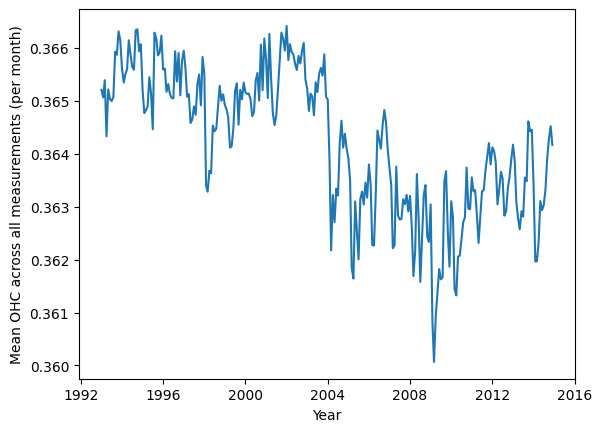

In [20]:
# sns.lineplot(df_monthly, x='Date', y='OHC')
plt.plot(df_monthly['Date'], df_monthly['OHC'])
plt.ylabel("Mean OHC across all measurements (per month)")
plt.xlabel("Year")

### Monthly counts

In [21]:
monthly_counts = df.groupby(df['Date'].dt.strftime('%m/%Y'))['OHC'].count().sort_values()

In [22]:
df_counts = pd.DataFrame(monthly_counts).reset_index()
df_counts['Date'] = pd.to_datetime(df_counts['Date'], format="%m/%Y")
df_counts = df_counts.sort_values('Date').reset_index(drop=True)
df_counts

,Date,OHC
0,1993-01-01,13324
1,1993-02-01,14610
2,1993-03-01,14416
3,1993-04-01,14908
4,1993-05-01,17116
...,...,...
259,2014-08-01,37850
260,2014-09-01,38768
261,2014-10-01,34376
262,2014-11-01,31270


In [23]:
monthly_argo_counts = argo_df.groupby(argo_df['Date'].dt.strftime('%m/%Y'))['OHC'].count().sort_values()
df_argo_counts = pd.DataFrame(monthly_argo_counts).reset_index()
df_argo_counts['Date'] = pd.to_datetime(df_argo_counts['Date'], format="%m/%Y")
df_argo_counts = df_argo_counts.sort_values('Date').reset_index(drop=True)
df_argo_counts

,Date,OHC
0,2000-01-01,526
1,2000-02-01,408
2,2000-03-01,442
3,2000-04-01,474
4,2000-05-01,504
...,...,...
175,2014-08-01,24804
176,2014-09-01,23956
177,2014-10-01,24312
178,2014-11-01,23628


In [24]:
month_list = pd.date_range('1993-1-1','2000-1-1', freq='MS').strftime('%m/%Y').tolist()
df_zeros = pd.DataFrame({
    "Date": month_list,
    "OHC": np.zeros(len(month_list)),
})
df_zeros['Date'] = pd.to_datetime(df_zeros['Date'], format="%m/%Y")
df_zeros

,Date,OHC
0,1993-01-01,0.0
1,1993-02-01,0.0
2,1993-03-01,0.0
3,1993-04-01,0.0
4,1993-05-01,0.0
...,...,...
80,1999-09-01,0.0
81,1999-10-01,0.0
82,1999-11-01,0.0
83,1999-12-01,0.0


(array([ 8401.,  8766.,  9131.,  9496.,  9862., 10227., 10592., 10957.,
        11323., 11688., 12053., 12418., 12784., 13149., 13514., 13879.,
        14245., 14610., 14975., 15340., 15706., 16071., 16436.]),
 [Text(8401.0, 0, '1993'),
  Text(8766.0, 0, '1994'),
  Text(9131.0, 0, '1995'),
  Text(9496.0, 0, '1996'),
  Text(9862.0, 0, '1997'),
  Text(10227.0, 0, '1998'),
  Text(10592.0, 0, '1999'),
  Text(10957.0, 0, '2000'),
  Text(11323.0, 0, '2001'),
  Text(11688.0, 0, '2002'),
  Text(12053.0, 0, '2003'),
  Text(12418.0, 0, '2004'),
  Text(12784.0, 0, '2005'),
  Text(13149.0, 0, '2006'),
  Text(13514.0, 0, '2007'),
  Text(13879.0, 0, '2008'),
  Text(14245.0, 0, '2009'),
  Text(14610.0, 0, '2010'),
  Text(14975.0, 0, '2011'),
  Text(15340.0, 0, '2012'),
  Text(15706.0, 0, '2013'),
  Text(16071.0, 0, '2014'),
  Text(16436.0, 0, '2015')])

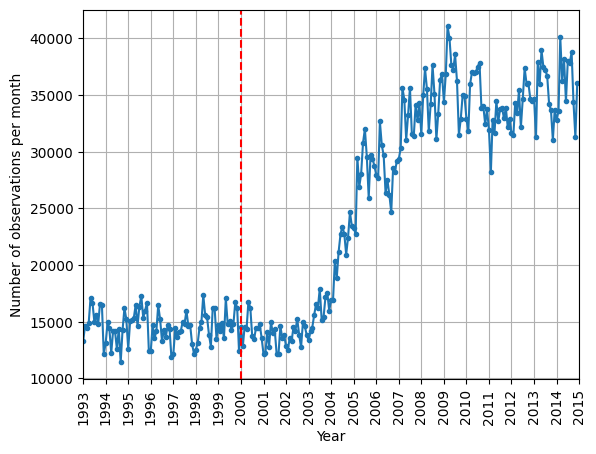

In [122]:
plt.plot(df_counts['Date'], df_counts['OHC'], marker='.')
plt.grid(True)
plt.ylabel("Number of observations per month")
plt.xlabel("Year")
plt.axvline(x=datetime.datetime(2000, 1, 1), c='red', ls='--')
ax = plt.gca()
ax.set_xlim([datetime.datetime(1993,1,1), datetime.datetime(2015,1,1)])

ax.xaxis.set_major_locator(YearLocator(1))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=90)


In [61]:
comp_df = pd.DataFrame()
comp_df['Date'] = pd.date_range(start = '1993-01-01', end = '2014-12-01', freq='MS')
comp_df['Date'] = pd.to_datetime(comp_df['Date'])
comp_df['Argo'] = pd.concat([df_zeros, pd.DataFrame(df_argo_counts)], ignore_index=True)['OHC']
comp_df['Other'] = pd.DataFrame(df_counts)['OHC'] - pd.concat([df_zeros, pd.DataFrame(df_argo_counts)], ignore_index=True)['OHC']
comp_df

,Date,Argo,Other
0,1993-01-01,0.0,13324.0
1,1993-02-01,0.0,14610.0
2,1993-03-01,0.0,14416.0
3,1993-04-01,0.0,14908.0
4,1993-05-01,0.0,17116.0
...,...,...,...
259,2014-08-01,25122.0,12728.0
260,2014-09-01,24804.0,13964.0
261,2014-10-01,23956.0,10420.0
262,2014-11-01,24312.0,6958.0


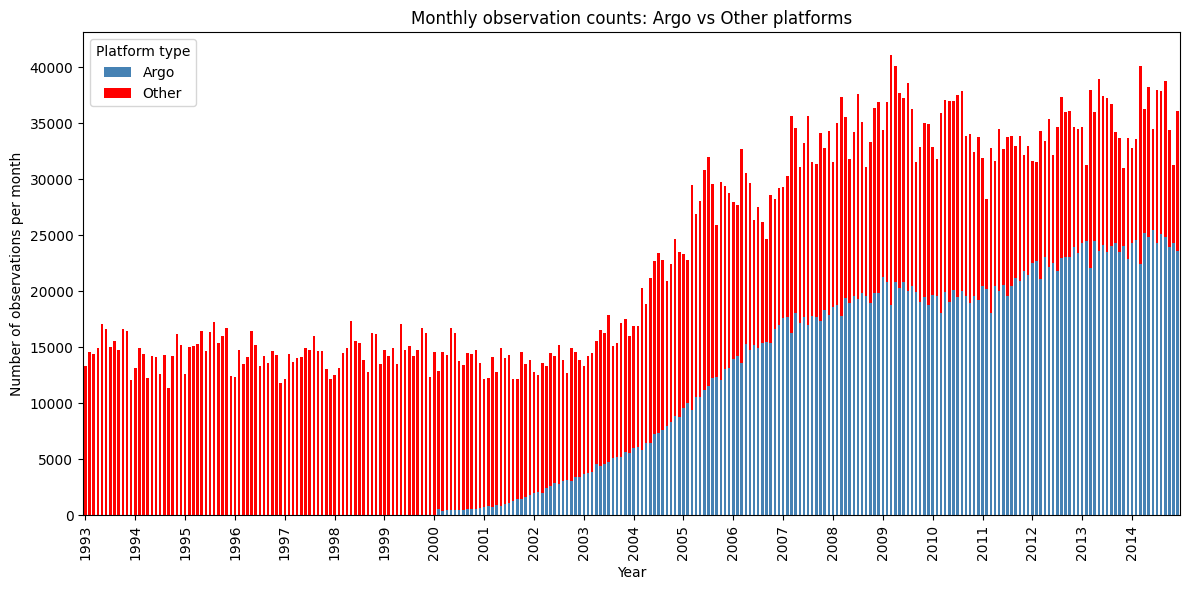

In [148]:
comp_df_plot = comp_df.set_index('Date')
comp_df_plot.index = comp_df_plot.index.to_period('M').year  # Using period indexing from pandas, without this get an error
ax = comp_df_plot.plot(kind='bar', stacked=True, color=['steelblue', 'red'], figsize=(12, 6), width=0.6)
ax.set_ylabel('Number of observations per month')
ax.set_xlabel('Year')
ax.set_title('Monthly observation counts: Argo vs Other platforms')

ax.xaxis.set_major_locator(MultipleLocator(12))  # Have stored years only as the period index, so shows only year
# If you want to plot by month, remove .year from comp_df_plot.index.to_period('M').year above and then will show months and years

plt.tight_layout()
plt.legend(title="Platform type")